# The Ultimate Challenge 

## Import Libraries

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import warnings
from datetime import timedelta
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")

## 1. Part 1 ‐ Exploratory data analysis
The attached `logins.json` file contains (simulated) timestamps of user logins in a particular
geographic location.


Aggregate these login counts based on **15minute time intervals**, and visualize and describe the resulting time series of login counts in ways that best characterize the
underlying patterns of the demand. 


Please report/illustrate important features of the demand, such as daily cycles. If there are data quality issues, please report them.


In [3]:
df = pd.read_json('logins.json')

In [4]:
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [5]:
df.shape

(93142, 1)

In [6]:
df.dtypes

login_time    datetime64[ns]
dtype: object

Adding a column to be able to aggregate the login count per 15 min interval

In [7]:
df['count'] = 1

In [8]:
df.head()

,login_time,count
0,1970-01-01 20:13:18,1
1,1970-01-01 20:16:10,1
2,1970-01-01 20:16:37,1
3,1970-01-01 20:16:36,1
4,1970-01-01 20:26:21,1


Aggregating with the frequency of 15 minutes, starting at 13 mins and 18 seconds, which corresponds to our first entry. 

In [9]:
df_agg = df.groupby([pd.Grouper(key='login_time', freq='15min', offset = '13min18second')]).sum('count')

In [10]:
df_agg.head()

,count
login_time,
1970-01-01 19:58:18,1
1970-01-01 20:13:18,7
1970-01-01 20:28:18,8
1970-01-01 20:43:18,6
1970-01-01 20:58:18,3


In [11]:
df_agg.shape

(9788, 1)

In [12]:
df_agg.reset_index(inplace= True)

Plotting the whole dataframe. 

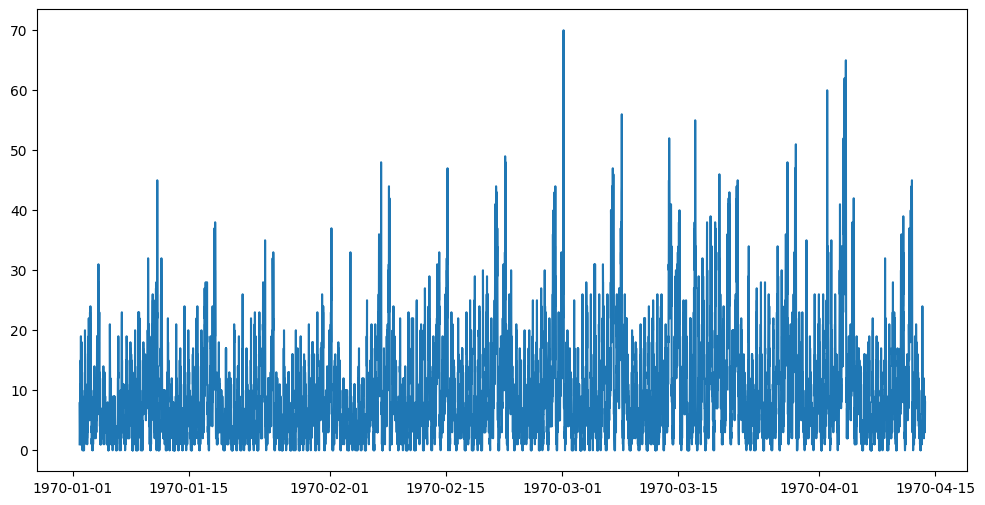

In [13]:
fig, ax = plt.subplots(figsize= (12,6))
plt.plot(df_agg['login_time'], df_agg['count'])
plt.show();

This does not show any specific pattern. We see spikes in login counts, but it is not easy to understand what days or time of the day they occur. Let's plot month by month to see if any pattern emerges. To do so, I first create dataframes for each month in the original dataframe.

In [87]:
january = df_agg[df_agg['login_time'] < '1970-02-01']
february = df_agg[(df_agg['login_time'] > '1970-02-01') & (df_agg['login_time'] < '1970-03-01')]
march = df_agg[(df_agg['login_time'] > '1970-03-01') & (df_agg['login_time'] < '1970-04-01')]
april = df_agg[df_agg['login_time'] > '1970-04-01']

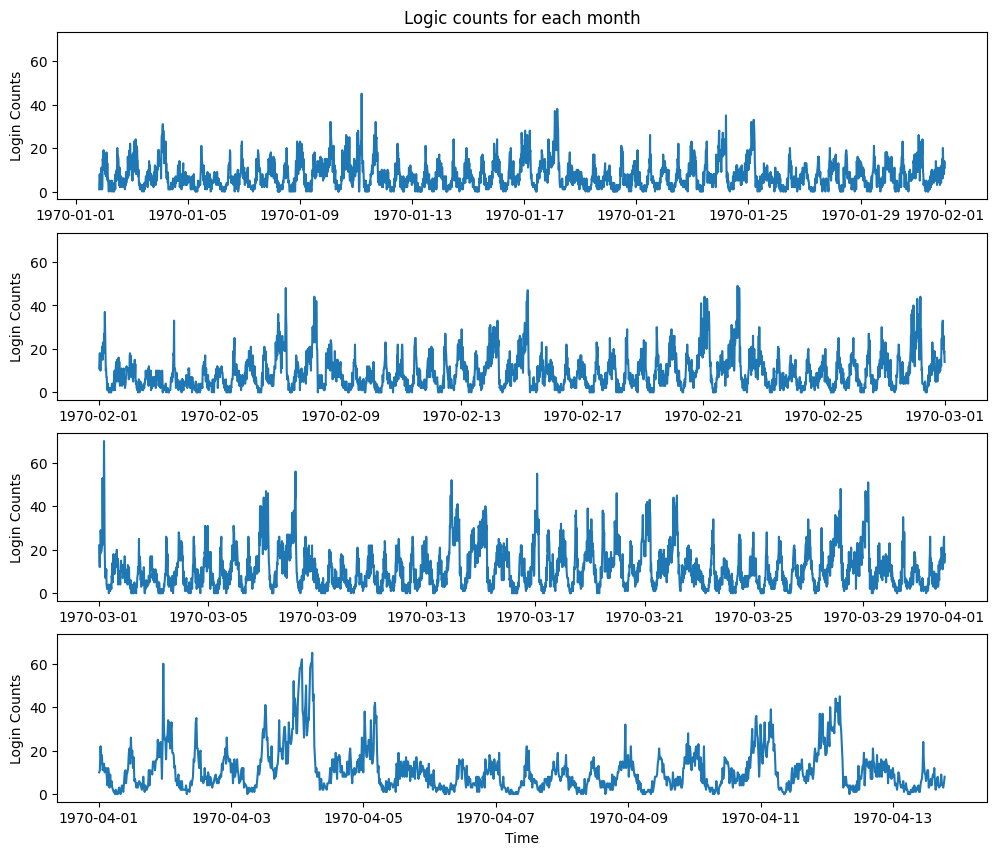

In [134]:
fig, ax = plt.subplots(4,1, sharey=True, figsize = (12,10)) 

ax[0].plot(january['login_time'], january['count'])

ax[1].plot(february['login_time'], february['count'])

ax[2].plot(march['login_time'], march['count'])

ax[3].plot(april['login_time'], april['count'])

ax[i].set_xlabel('Time')
for i in range(4):
    ax[i].set_ylabel('Login Counts')

ax[0].set_title('Logic counts for each month')

plt.show();

Although it is still unclear from the charts when the spikes in usage occur, we can safely say we are dealing with "additive" seasonality ([Ref](https://sigmundojr.medium.com/seasonality-in-python-additive-or-multiplicative-model-d4b9cf1f48a7)). 

In order to have a better understaning of the spikes, we can look at the login times on a daily basis. Let's do so for a few days. 


In [124]:
january_1st = january[january['login_time'] < '1970-01-02']
february_1st = february[february['login_time'] < '1970-02-02']
march_1st = march[march['login_time'] < '1970-03-02']
april_1st = april[april['login_time'] < '1970-04-02']


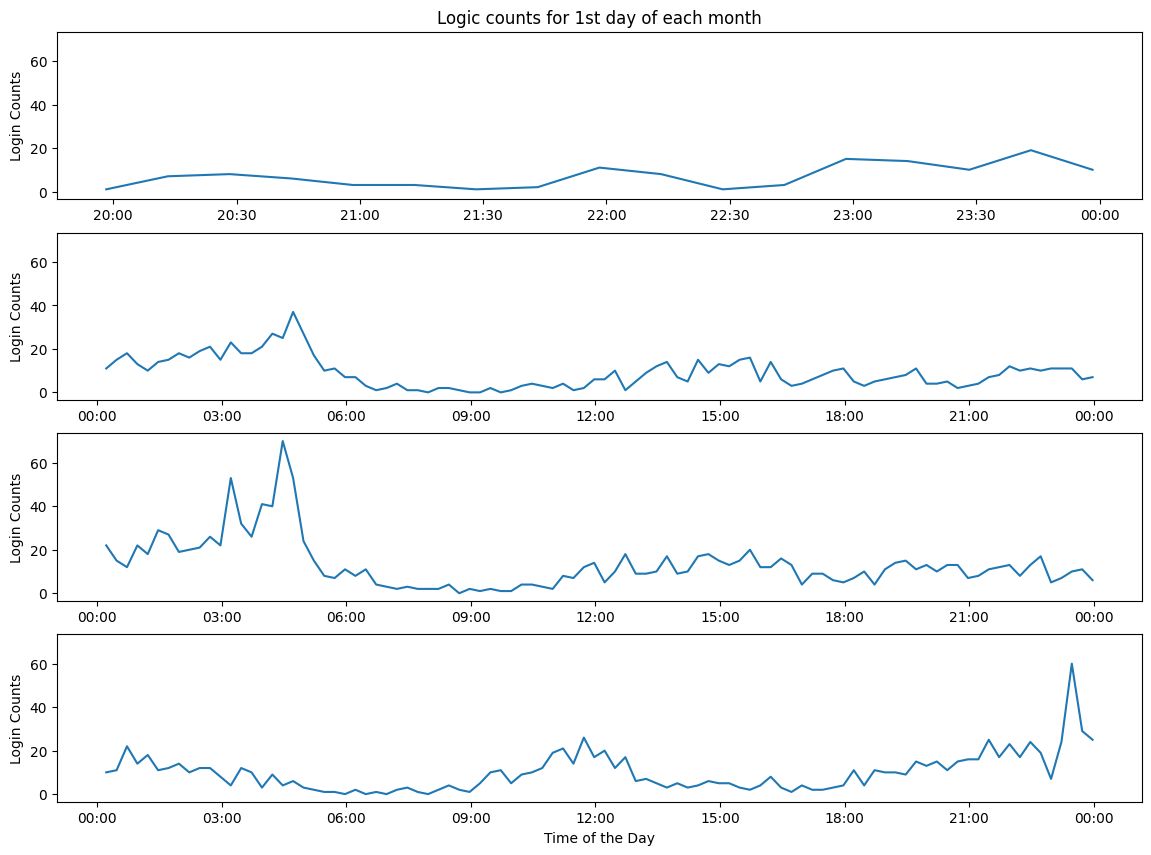

In [133]:

fig, ax = plt.subplots(4,1, sharey=True, figsize = (14,10)) 

ax[0].plot(january_1st['login_time'], january_1st['count'])

ax[1].plot(february_1st['login_time'], february_1st['count'])

ax[2].plot(march_1st['login_time'], march_1st['count'])

ax[3].plot(april_1st['login_time'], april_1st['count'])

ax[i].set_xlabel('Time of the Day')
for i in range(4):
    ax[i].set_ylabel('Login Counts')
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax[0].set_title('Logic counts for 1st day of each month')
plt.show();

Comparing the 4 months more quantitavely.

In [137]:
january.describe()

,login_time,count,hour,minute,second
count,2897,2897.000000,2897.000000,2897.000000,2897.0
mean,1970-01-16 21:58:18,7.335174,11.557818,35.507767,18.0
min,1970-01-01 19:58:18,0.000000,0.000000,13.000000,18.0
25%,1970-01-09 08:58:18,3.000000,6.000000,28.000000,18.0
50%,1970-01-16 21:58:18,6.000000,12.000000,43.000000,18.0
75%,1970-01-24 10:58:18,10.000000,18.000000,58.000000,18.0
max,1970-01-31 23:58:18,45.000000,23.000000,58.000000,18.0
std,NaN,6.088027,6.944595,16.775719,0.0


In [141]:
january[january['count'] == january['count'].max()] 

,login_time,count,hour,minute,second
899,1970-01-11 04:43:18,45,4,43,18


In [142]:
january_1st.describe()

,login_time,count,hour,minute,second
count,17,17.000000,17.000000,17.000000,17.0
mean,1970-01-01 21:58:18,7.176471,21.352941,36.823529,18.0
min,1970-01-01 19:58:18,1.000000,19.000000,13.000000,18.0
25%,1970-01-01 20:58:18,3.000000,20.000000,28.000000,18.0
50%,1970-01-01 21:58:18,7.000000,21.000000,43.000000,18.0
75%,1970-01-01 22:58:18,10.000000,22.000000,58.000000,18.0
max,1970-01-01 23:58:18,19.000000,23.000000,58.000000,18.0
std,NaN,5.445586,1.271868,17.636026,0.0


In [143]:
january_1st[january_1st['count'] == january_1st['count'].max()] 

,login_time,count,hour,minute,second
15,1970-01-01 23:43:18,19,23,43,18


For January, the average number of login counts is almost `7` and the max is `45`. The login time with the most logins is '04:43:18' on January 11th.

The maximum number of logins on January 1st is `19`, happening at '23:43:18'.

In [138]:
february.describe()

,login_time,count,hour,minute,second
count,2688,2688.000000,2688.000000,2688.00000,2688.0
mean,1970-02-15 00:05:48,9.179688,11.500000,35.50000,18.0
min,1970-02-01 00:13:18,0.000000,0.000000,13.00000,18.0
25%,1970-02-08 00:09:33,3.000000,5.750000,24.25000,18.0
50%,1970-02-15 00:05:48,7.000000,11.500000,35.50000,18.0
75%,1970-02-22 00:02:03,13.000000,17.250000,46.75000,18.0
max,1970-02-28 23:58:18,49.000000,23.000000,58.00000,18.0
std,NaN,7.812137,6.923475,16.77363,0.0


In [144]:
february[february['count'] == february['count'].max()] 

,login_time,count,hour,minute,second
4926,1970-02-22 03:28:18,49,3,28,18


In [145]:
february_1st.describe()

,login_time,count,hour,minute,second
count,96,96.000000,96.000000,96.000000,96.0
mean,1970-02-01 12:05:48,9.010417,11.500000,35.500000,18.0
min,1970-02-01 00:13:18,0.000000,0.000000,13.000000,18.0
25%,1970-02-01 06:09:33,3.750000,5.750000,24.250000,18.0
50%,1970-02-01 12:05:48,7.000000,11.500000,35.500000,18.0
75%,1970-02-01 18:02:03,13.000000,17.250000,46.750000,18.0
max,1970-02-01 23:58:18,37.000000,23.000000,58.000000,18.0
std,NaN,7.102994,6.958524,16.858545,0.0


In [146]:
february_1st[february_1st['count'] == february_1st['count'].max()] 

,login_time,count,hour,minute,second
2915,1970-02-01 04:43:18,37,4,43,18


For February, the average number of login counts is almost `9` and the max is `49`. The login time with the most logins is '03:28:18' on February 22nd.

The maximum number of logins on February 1st is `37`, happening at '04:43:18'.

In [139]:
march.describe()

,login_time,count,hour,minute,second
count,2976,2976.000000,2976.00000,2976.000000,2976.0
mean,1970-03-16 12:05:48,11.332325,11.50000,35.500000,18.0
min,1970-03-01 00:13:18,0.000000,0.00000,13.000000,18.0
25%,1970-03-08 18:09:33,4.000000,5.75000,24.250000,18.0
50%,1970-03-16 12:05:48,9.000000,11.50000,35.500000,18.0
75%,1970-03-24 06:02:03,16.000000,17.25000,46.750000,18.0
max,1970-03-31 23:58:18,70.000000,23.00000,58.000000,18.0
std,NaN,9.352739,6.92335,16.773328,0.0


In [147]:
march[march['count'] == march['count'].max()] 

,login_time,count,hour,minute,second
5602,1970-03-01 04:28:18,70,4,28,18


In [148]:
march_1st.describe()

,login_time,count,hour,minute,second
count,96,96.000000,96.000000,96.000000,96.0
mean,1970-03-01 12:05:48,13.177083,11.500000,35.500000,18.0
min,1970-03-01 00:13:18,0.000000,0.000000,13.000000,18.0
25%,1970-03-01 06:09:33,6.000000,5.750000,24.250000,18.0
50%,1970-03-01 12:05:48,11.000000,11.500000,35.500000,18.0
75%,1970-03-01 18:02:03,16.250000,17.250000,46.750000,18.0
max,1970-03-01 23:58:18,70.000000,23.000000,58.000000,18.0
std,NaN,11.615774,6.958524,16.858545,0.0


In [149]:
march_1st[march_1st['count'] == march_1st['count'].max()] 

,login_time,count,hour,minute,second
5602,1970-03-01 04:28:18,70,4,28,18


For March, the average number of login counts is almost `13` and the max is `70`. The login time with the most logins is '04:28:18' on March 1st.



In [140]:
april.describe()

,login_time,count,hour,minute,second
count,1227,1227.000000,1227.000000,1227.000000,1227.0
mean,1970-04-07 09:28:18.000000001,10.995925,11.339853,35.481663,18.0
min,1970-04-01 00:13:18,0.000000,0.000000,13.000000,18.0
25%,1970-04-04 04:50:48,4.000000,5.000000,20.500000,18.0
50%,1970-04-07 09:28:18,8.000000,11.000000,28.000000,18.0
75%,1970-04-10 14:05:48,15.000000,17.000000,43.000000,18.0
max,1970-04-13 18:43:18,65.000000,23.000000,58.000000,18.0
std,NaN,9.985347,6.871061,16.771868,0.0


In [151]:
april[april['count'] == april['count'].max()] 

,login_time,count,hour,minute,second
8870,1970-04-04 05:28:18,65,5,28,18


In [152]:
april_1st.describe()

,login_time,count,hour,minute,second
count,96,96.000000,96.000000,96.000000,96.0
mean,1970-04-01 12:05:48,9.854167,11.500000,35.500000,18.0
min,1970-04-01 00:13:18,0.000000,0.000000,13.000000,18.0
25%,1970-04-01 06:09:33,3.000000,5.750000,24.250000,18.0
50%,1970-04-01 12:05:48,9.000000,11.500000,35.500000,18.0
75%,1970-04-01 18:02:03,14.000000,17.250000,46.750000,18.0
max,1970-04-01 23:58:18,60.000000,23.000000,58.000000,18.0
std,NaN,8.856730,6.958524,16.858545,0.0


In [153]:
april_1st[april_1st['count'] == april_1st['count'].max()] 

,login_time,count,hour,minute,second
8654,1970-04-01 23:28:18,60,23,28,18


For April, the average number of login counts is almost `10` and the max is `65`. The login time with the most logins is '05:28:18' on April 4th.

The maximum number of logins on February 1st is `60`, happening at '23:28:18'.

Some pattern emerges when we look at the monthly data. We see that the most number of logins happen in early mornings, '04:43:18' on January 11th, '03:28:18' on February 22nd, '04:28:18' on March 1st and '05:28:18' on April 4th.   

However, there is no clear pattern of the day of the month when there seems to be more logins.  

##  Part 2 ‐ Experiment and metrics design
The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on
weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active
during the day. On weekends, there is reasonable activity in both cities.
However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend
to be exclusive to each city. The Ultimate managers of city operations for the two cities have
proposed an experiment to encourage driver partners to be available in both cities, by
reimbursing all toll costs.

1) What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?
2) Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on:
   
    a) how you will implement the experiment <br>
    b) what statistical test(s) you will conduct to verify the significance of the observation <br>
    c) how you would interpret the results and provide recommendations to the city operations team along with any caveats. <br>


### 2.1. Answer 1

1) Since the idea is to have driver partners from opposite cities in the target city during the week, the success would come down to observing Gotham driver partners in Metropolis during the day, and Metroplois drivers at Gotham at night on weekdays. In other words, we would need to see the following happening during weekdays in the two cities.

| Activity Type       | Weekday Day Time      | Weekday Night Time        |
|---------------------|----------------|--------------------|
| Normal              | Metropolis     | Gotham             |
| Experimental        | Metropolis cars present at Gotham | Gotham cars present at Metropolis|

Success can be measured by an increase in the percentage of such drivers in the respective cities.





### 2.2. Answer 2

#### 2.2.a. Answer 2a)
2) For a period of one month, the number of drivers in both cities, broken down to which city they belong to. will be collected.
   
If the numbers  of present drivers for the oppsoite city keeps increasing over time and is more than the observed activity during the same month in a previous year (or years), then we can conclude that the experiment is successfull. Note that if any upward trajectory is observed, it will probably be in the beginning, and will probably plateau later. 

By the same token, the larger number of cars in one city means a similar decrease in the opposite city. If the drivers of Metropolis start going to Gotham more often during day time, the number of cars in the Metropolis city will show a decrease of a similar rate. That means once we reach a pleatu in the number of cars in each city, the numbers should balance out the number of cars in the second city. 

However, the plateaued line should show an increase compared to the previous year. The following plot shows a hypothetical measure of success. 

In [104]:

# creating hypothetical numbers 

dates = pd.Series(range(1,31))

# current numbers
met_day = pd.Series(np.random.randint(100,140, 30))
goth_night = pd.Series(np.random.randint(110,150, 30))

met_night = pd.Series(np.random.randint(10,14, 30))
goth_day = pd.Series(np.random.randint(11,13, 30))


# projected numbers
met_night_pro = pd.concat([
    pd.Series(range(20, 81, 3)),
    pd.Series([81] * 9)
    ], ignore_index=True)

met_day_pro = pd.concat([
    pd.Series(range(140, 79, -3)),
    pd.Series([79] * 9)
    ], ignore_index=True)

goth_day_pro = pd.concat([
    pd.Series(range(20, 81, 3)),
    pd.Series([81] * 9)
    ], ignore_index=True)

goth_night_pro = pd.concat([
    pd.Series(range(150, 83, -3)),
    pd.Series([79] * 7)
    ], ignore_index=True)

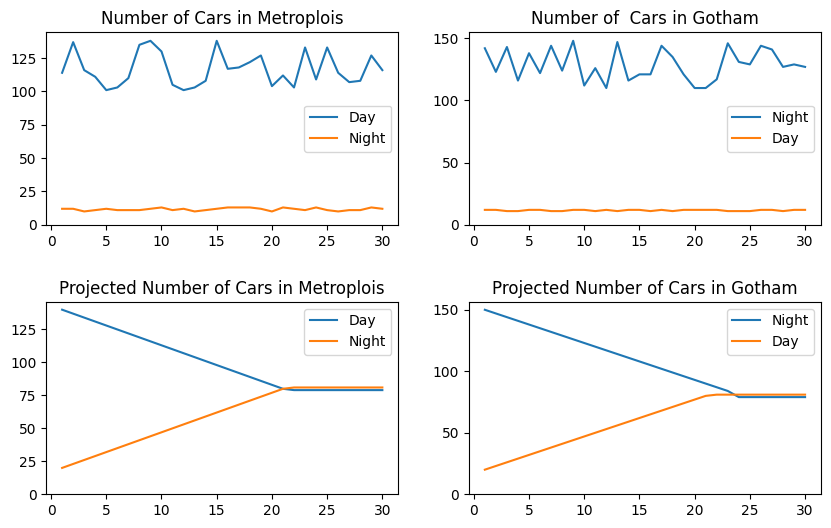

In [118]:

fig, ax = plt.subplots(2,2, figsize = (10,6))

# Current situation
ax[0,0].plot(dates, met_day, label = 'Day')
ax[0,0].plot(dates, met_night, label = 'Night')
ax[0,0].set_ylim(bottom=0) 
ax[0,0].set_title('Number of Cars in Metroplois')
ax[0,0].legend()


ax[0,1].plot(dates, goth_night, label = 'Night')
ax[0,1].plot(dates, goth_day, label = 'Day')
ax[0,1].set_ylim(bottom=0) 
ax[0,1].set_title('Number of  Cars in Gotham')
ax[0,1].legend()


# Successful situation 
ax[1,0].plot(dates, met_day_pro, label = 'Day')
ax[1,0].plot(dates, met_night_pro, label = 'Night')
ax[1,0].set_ylim(bottom=0) 
ax[1,0].set_title('Projected Number of Cars in Metroplois')
ax[1,0].legend()

ax[1,1].plot(dates, goth_night_pro, label = 'Night')
ax[1,1].plot(dates, goth_day_pro, label = 'Day')
ax[1,1].set_ylim(bottom=0) 
ax[1,1].set_title('Projected Number of Cars in Gotham')
ax[1,1].legend()

plt.subplots_adjust(hspace=0.4)

plt.show();



In the end, the success would look like the following where the number of cars during day and night in both cities balance each other. 

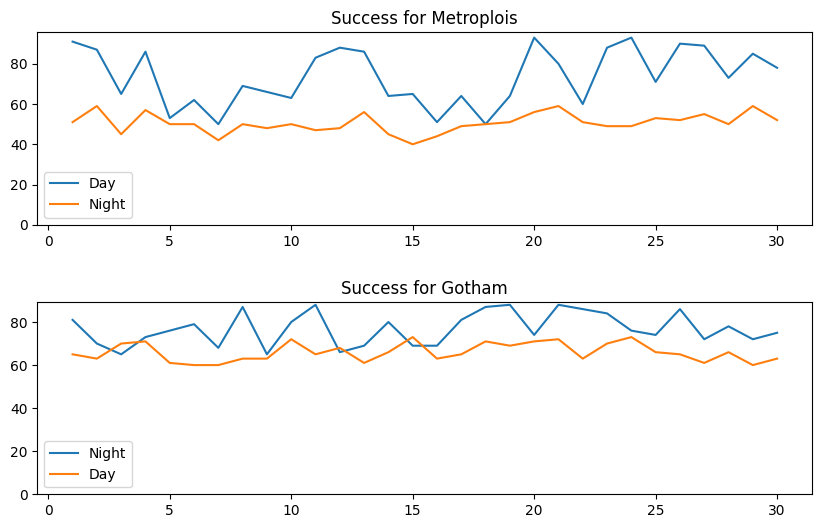

In [119]:
met_day_success = pd.Series(np.random.randint(50, 94, 30))
met_night_success = pd.Series(np.random.randint(40,60, 30))

goth_night_success = pd.Series(np.random.randint(65,90, 30))
goth_day_success = pd.Series(np.random.randint(60,74, 30))


fig, ax = plt.subplots(2,1, figsize = (10,6))

# Current situation
ax[0].plot(dates, met_day_success, label = 'Day')
ax[0].plot(dates, met_night_success, label = 'Night')
ax[0].set_ylim(bottom=0)
ax[0].set_title('Success for Metroplois')
ax[0].legend()


ax[1].plot(dates, goth_night_success, label = 'Night')
ax[1].plot(dates, goth_day_success, label = 'Day')
ax[1].set_ylim(bottom=0) 
ax[1].set_title('Success for Gotham')
ax[1].legend()

plt.subplots_adjust(hspace=0.4)

plt.show();

#### 2.2.b/c. Answer b) and c)

To begin with, we need to have a `null hypothesis` and an `alternative hypothesis`, defined below:

**H<sub>null</sub>:** There is no significant change in the driver activity in the two cities. Any change observed is due to chance.

**H<sub>alternative</sub>:** There is a change in the driver activity in the two cities, and it is not due to chance. 


The significance level of 0.05 is chosen to evaluate the null hypothesis. 

The change in the driver activity would be evaluated against the new policy of "toll reimbursement" by investigating whether the change (if any) is significant by calculating the relevant *p-value* using **permutation test**. If this value is equal or less than our chosen significance level, we can reject the null hypothesis, meaning that the observed change in the activity is due to the new policy. 


If the experiment shows statistically significant changes, our recommendation would be to move ahead with the proposed method of toll reimbursement. On the other hand, if it does not show significant change, we can roll back the toll free option. 

Caveat???

## 3. Part 3 ‐ Predictive modeling

Ultimate is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an Ultimate account in
January 2014. The data was pulled several months later; we consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days.

We would like you to use this data set to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help Ultimate.

The data is in the attached file `ultimate_data_challenge.json`. See below for a detailed
description of the dataset. Please include any code you wrote for the analysis and delete the
dataset when you have finished with the challenge.

1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?
3. Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.
4. Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

### 3.1. EDA, Visualization

In [125]:
df = pd.read_json('ultimate_data_challenge.json')

In [126]:
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


#### 3.1.1. Checking spellings

In [127]:
# Checking to see if there are multiple spellings for the cities
df['city'].unique()

array(["King's Landing", 'Astapor', 'Winterfell'], dtype=object)

In [128]:
# Checking to see if there are multiple spellings for the ultimate_black_user
df['ultimate_black_user'].unique()

array([ True, False])

In [131]:
# Checking to see if there are multiple spellings for the phone types
df['phone'].unique()

array(['iPhone', 'Android', None], dtype=object)

#### 3.1.2. Checking values

In [129]:
# making sure the ratings is between 1 and 5
df['avg_rating_of_driver'].describe()

count    41878.000000
mean         4.601559
std          0.617338
min          1.000000
25%          4.300000
50%          4.900000
75%          5.000000
max          5.000000
Name: avg_rating_of_driver, dtype: float64

In [130]:
# making sure the ratings is between 1 and 5
df['avg_rating_by_driver'].describe()

count    49799.000000
mean         4.778158
std          0.446652
min          1.000000
25%          4.700000
50%          5.000000
75%          5.000000
max          5.000000
Name: avg_rating_by_driver, dtype: float64

#### 3.1.3. Dealing with `null` values

In [132]:
# investigating the None value for the phone
df[df['phone'].isnull()]

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
134,King's Landing,0,2014-01-10,5.0,1.00,2014-06-11,None,0.0,False,100.0,2.88,5.0
176,Astapor,0,2014-01-28,5.0,1.00,2014-03-18,None,0.0,False,100.0,20.32,5.0
320,Astapor,1,2014-01-08,5.0,1.00,2014-01-09,None,0.0,False,100.0,31.01,5.0
349,Winterfell,1,2014-01-06,3.3,1.00,2014-06-22,None,0.0,True,33.3,6.03,5.0
389,King's Landing,5,2014-01-26,4.9,1.02,2014-07-01,None,3.0,False,66.7,3.08,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...
49587,Winterfell,1,2014-01-17,5.0,1.00,2014-01-19,None,0.0,True,0.0,1.15,3.0
49627,Astapor,6,2014-01-05,5.0,1.00,2014-01-25,None,0.0,True,33.3,3.10,4.5
49666,Winterfell,2,2014-01-22,NaN,1.00,2014-01-23,None,0.0,True,100.0,0.73,5.0
49825,Astapor,0,2014-01-25,5.0,1.00,2014-03-10,None,0.0,True,50.0,5.82,5.0


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [134]:
df.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

The `null` values for phone type should, in principal, be inconsequential. However, the differences in the phone apps might make it harder for android versus iphone users. I'll drop the `null` values for this reason.   

In [135]:
df.dropna(subset = ['phone'], how= 'any', inplace = True, axis = 0)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49604 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    49604 non-null  object 
 1   trips_in_first_30_days  49604 non-null  int64  
 2   signup_date             49604 non-null  object 
 3   avg_rating_of_driver    41578 non-null  float64
 4   avg_surge               49604 non-null  float64
 5   last_trip_date          49604 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               49604 non-null  float64
 8   ultimate_black_user     49604 non-null  bool   
 9   weekday_pct             49604 non-null  float64
 10  avg_dist                49604 non-null  float64
 11  avg_rating_by_driver    49406 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.6+ MB


In [137]:
df[df['avg_rating_of_driver'].isnull()]

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
6,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,Android,0.0,False,100.0,3.95,4.0
9,Winterfell,1,2014-01-03,NaN,1.0,2014-01-05,Android,0.0,False,0.0,2.37,5.0
12,Winterfell,1,2014-01-15,NaN,1.0,2014-03-12,iPhone,0.0,False,100.0,20.29,5.0
14,Astapor,1,2014-01-27,NaN,1.0,2014-01-28,Android,0.0,False,100.0,26.01,5.0
15,Winterfell,1,2014-01-15,NaN,1.0,2014-01-16,Android,0.0,True,100.0,13.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
49984,Winterfell,1,2014-01-26,NaN,1.0,2014-01-26,Android,0.0,False,0.0,3.50,5.0
49985,Astapor,1,2014-01-26,NaN,1.0,2014-02-25,Android,0.0,False,100.0,1.38,5.0
49989,Winterfell,1,2014-01-24,NaN,1.0,2014-01-31,iPhone,0.0,False,100.0,0.00,5.0
49996,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0


It does not seem to have any bearing in the retention of the drivers. Same goes for `avg_rating_by_driver`. I will fill these `null` values with the mean of the column.

In [138]:
df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].mean(), inplace=True)
df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean(), inplace=True)


In [139]:
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49604 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    49604 non-null  object 
 1   trips_in_first_30_days  49604 non-null  int64  
 2   signup_date             49604 non-null  object 
 3   avg_rating_of_driver    49604 non-null  float64
 4   avg_surge               49604 non-null  float64
 5   last_trip_date          49604 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               49604 non-null  float64
 8   ultimate_black_user     49604 non-null  bool   
 9   weekday_pct             49604 non-null  float64
 10  avg_dist                49604 non-null  float64
 11  avg_rating_by_driver    49604 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.6+ MB


In [141]:
df.isnull().sum()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
dtype: int64

#### 3.1.4. Correcting the types 

We need to change the following data types:

- signup_date: from `object` to `datetime`
- last_trip_date: from `object` to `datetime`

In [142]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49604 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    49604 non-null  object        
 1   trips_in_first_30_days  49604 non-null  int64         
 2   signup_date             49604 non-null  datetime64[ns]
 3   avg_rating_of_driver    49604 non-null  float64       
 4   avg_surge               49604 non-null  float64       
 5   last_trip_date          49604 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   surge_pct               49604 non-null  float64       
 8   ultimate_black_user     49604 non-null  bool          
 9   weekday_pct             49604 non-null  float64       
 10  avg_dist                49604 non-null  float64       
 11  avg_rating_by_driver    49604 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int64(1)

#### 3.1.5. Visualization

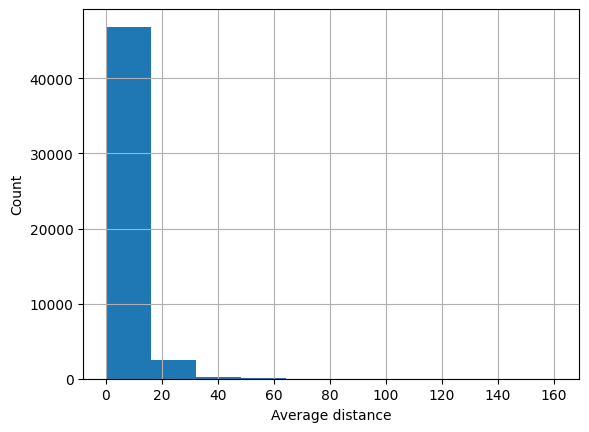

In [144]:
df['avg_dist'].hist()
plt.xlabel('Average distance')
plt.ylabel('Count')
plt.show();

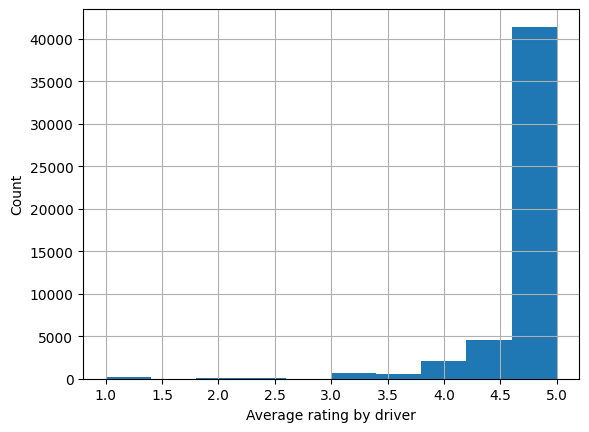

In [145]:
df['avg_rating_by_driver'].hist()
plt.xlabel('Average rating by driver')
plt.ylabel('Count')
plt.show();

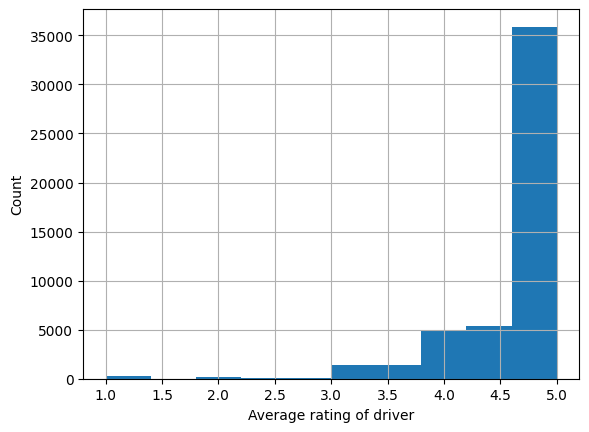

In [146]:
df['avg_rating_of_driver'].hist()
plt.xlabel('Average rating of driver')
plt.ylabel('Count')
plt.show();

### 3.2 : Modeling

The dependent variable we are trying to predict is whether the driver was retained or not. 

To do so, we first need to do some feature engineeing and convert categorical values into numeric ones. 

#### 3.2.1. Feature Engineering

In [147]:
# create a new column calculating the number of days passed from today's date (the latest date in the df) and the user's last trip date
df['last_trip_delta'] = df['last_trip_date'].max() - df['last_trip_date']

In [148]:
# create a new column with the retention information
df['retained'] = df['last_trip_delta'].apply(lambda x: 1 if x <= timedelta(days=30) else 0) 

In [149]:
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,last_trip_delta,retained
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,14 days,1
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,57 days,0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,175 days,0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,2 days,1
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,108 days,0


In [150]:
df['retained'].value_counts()

retained
0    30933
1    18671
Name: count, dtype: int64

In [151]:
print('Percentage of retained drivers:' , round(df['retained'].value_counts()[1]/ df['retained'].count() * 100, 2), '%')

Percentage of retained drivers: 37.64 %


#### 3.2.2. Investigating feature correlations 

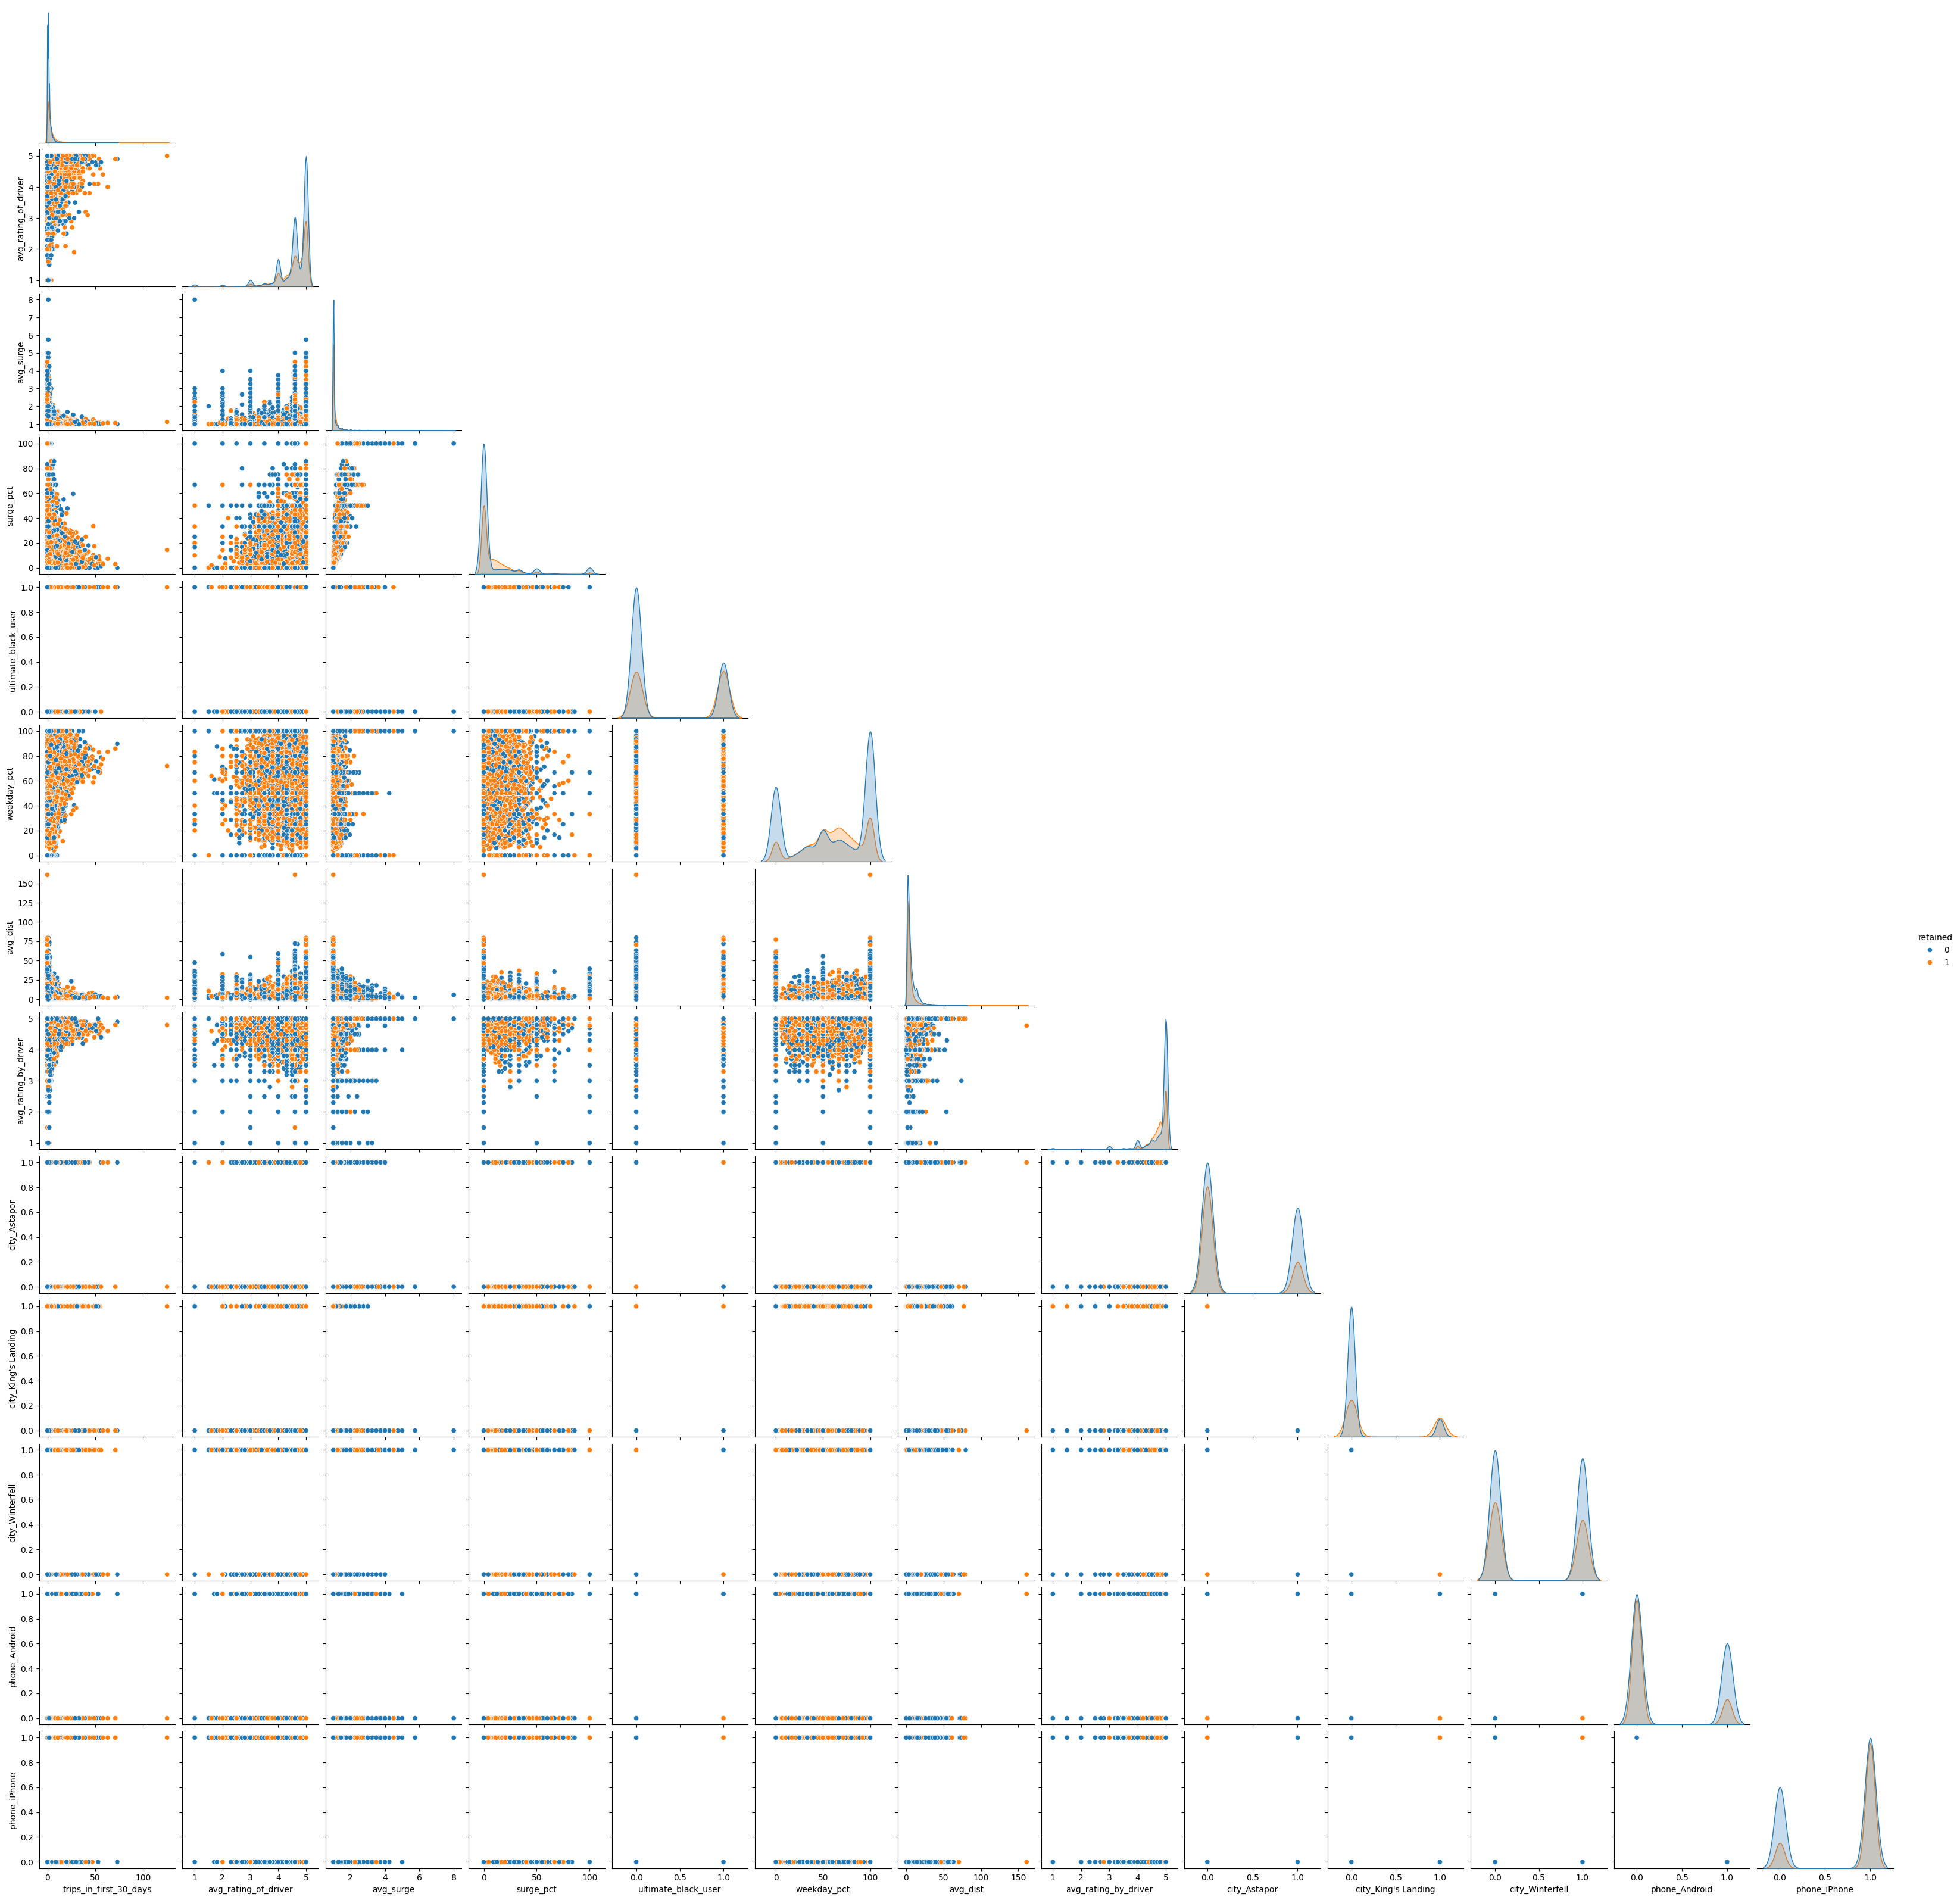

In [183]:
sns.pairplot(df, corner = True, hue = 'retained')

plt.savefig('pairplot.png')
plt.show();

The pairplot above gives us some idea of the correlation between independant variables and the dependant one. However, a heatmap can quantify this for us. 

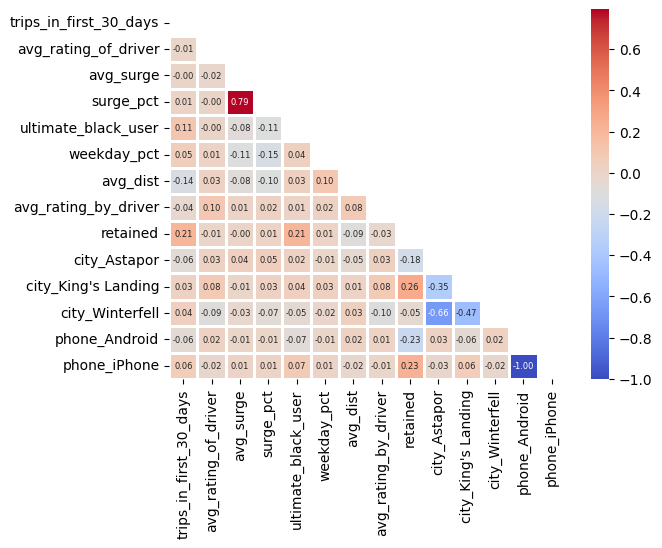

In [184]:
sns.heatmap(df.corr(),
            annot = True,
            fmt=".2f",
            cmap='coolwarm',
            annot_kws={"size": 6},
            linewidths=0.8,
            mask = np.triu(df.corr()));

It is safe to say there is no linear correlation between variables. So, the modeling used here is going to be `Logistic Regression`. Another reason is that the dependent variable we are trying to predict is binary. In other words, this is a classification problem and suitable for `Logistic Regression`.


#### 3.2.3. Categorical $\rightarrow$ Numeric Conversion

In [153]:
# replacing the categorical values with numeric ones

df = pd.get_dummies(df)

df.head()

,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,last_trip_delta,retained,city_Astapor,city_King's Landing,city_Winterfell,phone_Android,phone_iPhone
0,4,2014-01-25,4.7,1.10,2014-06-17,15.4,True,46.2,3.67,5.0,14 days,1,False,True,False,False,True
1,0,2014-01-29,5.0,1.00,2014-05-05,0.0,False,50.0,8.26,5.0,57 days,0,True,False,False,True,False
2,3,2014-01-06,4.3,1.00,2014-01-07,0.0,False,100.0,0.77,5.0,175 days,0,True,False,False,False,True
3,9,2014-01-10,4.6,1.14,2014-06-29,20.0,True,80.0,2.36,4.9,2 days,1,False,True,False,False,True
4,14,2014-01-27,4.4,1.19,2014-03-15,11.8,False,82.4,3.13,4.9,108 days,0,False,False,True,True,False


#### 3.2.4. Train/Test Split

In [155]:
# dropping date columns 
df.drop(columns = ['signup_date', 'last_trip_date', 'last_trip_delta'], axis = 1, inplace = True)

Before movig forward, since this is a classification problem, it is better to check if our data is balanced. We saw above that it is not with %37.6 of the drivers retained. Let's visualize it here. 

In [156]:
class_counts = df['retained'].value_counts()
class_counts

retained
0    30933
1    18671
Name: count, dtype: int64

In [157]:
class_percentages = pd.Series([(x / df.shape[0]) * 100.00 for x in class_counts])
class_percentages

0    62.35989
1    37.64011
dtype: float64

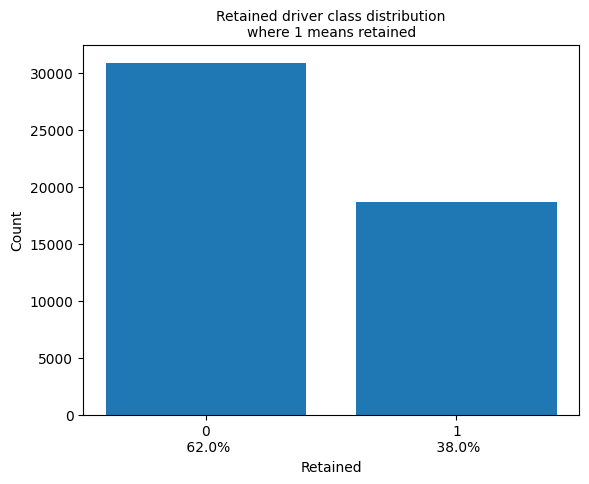

In [158]:
fig, ax = plt.subplots()
ax.bar(class_counts.index, class_counts)
ax.set_xticks([0, 1])
ax.set_xticklabels(class_percentages.index.astype(str) + '\n' + ' ' +
                   class_percentages.round(0).astype(str) + '%')
ax.set_ylabel('Count')
ax.set_xlabel('Retained')
ax.set_title('Retained driver class distribution\nwhere 1 means retained',
              fontsize = 10)
plt.show()

Given that the data is imbalanced, I use the `stratify` argument while splitting the data into training and testing to keep the class distibution similar in training and test samples, 

In [227]:
#subsetting data into independant and dependent variables

X = df.drop(columns = ['retained'], axis =1)
y = df[['retained']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,  stratify = y)


In [228]:
print("shape of training data, independent variable: ", X_train.shape)
print("shape of training data, dependent variable: ", y_train.shape, '\n')
print("shape of test data, independent variable: ", X_test.shape)
print("shape of test data, dependent variable: ", y_test.shape)

shape of training data, independent variable:  (37203, 13)
shape of training data, dependent variable:  (37203, 1) 

shape of test data, independent variable:  (12401, 13)
shape of test data, dependent variable:  (12401, 1)


#### 3.2.5. Model 1- all variables

In [229]:
### Logistic regression model
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
logR = linear_model.LogisticRegression()

In [230]:
logR.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [231]:
print(logR.score(X_test_scaled, y_test))


0.7178453350536247


This seems to be already a good model. But, let's check the metrics to see how good it actually is. 

In [232]:
y_pred = logR.predict(X_test_scaled)

In [233]:
print("[Training] Accuracy score:", 
      f'{accuracy_score(y_train, logR.predict(X_train)):.2f}')

[Training] Accuracy score: 0.65


In [234]:
print("[Test] Accuracy score:",
      f'{accuracy_score(y_pred, y_test):.2f}')

[Test] Accuracy score: 0.72


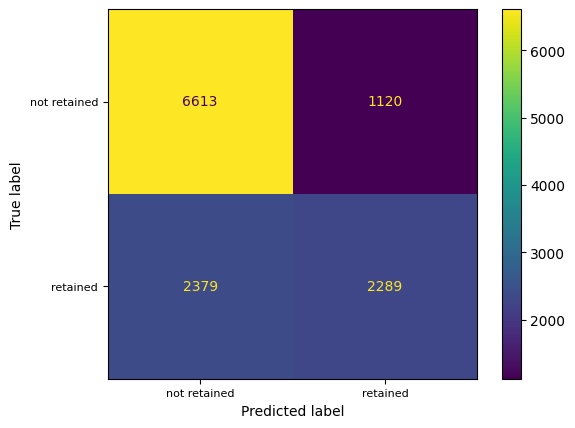

In [235]:
cm = confusion_matrix(y_test, y_pred, labels = logR.classes_)
_, ax = plt.subplots()
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm, 
                                    display_labels = ['not retained', 'retained'])
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels = ['not retained', 'retained'], fontsize = 8)
ax.set_yticklabels(labels = ['not retained', 'retained'], fontsize = 8)
display_cm.plot(ax = ax);

In [236]:
print("[Test Classification Report]")
print(classification_report(y_test, y_pred))

[Test Classification Report]
              precision    recall  f1-score   support

           0       0.74      0.86      0.79      7733
           1       0.67      0.49      0.57      4668

    accuracy                           0.72     12401
   macro avg       0.70      0.67      0.68     12401
weighted avg       0.71      0.72      0.71     12401



Let's break down the numbers a little bit here:

- Positive/Retained Class 
    - The **recall** value of 0.51 means that of all actual retained customers, only **51%** were correctly predicted.

    - The **precision** value of 0.68 means of all customers predicted as retained, **68%** were actually retained.

- Negative/Lapsed Class 

    - The **recall** value of 0.85 means that of all actual retained customers, only **85%** were correctly predicted.

    - The **precision** value of 0.74 means of all customers predicted as retained, **74%** were actually retained.


Since our goal here is to catch the lapsed customers, this model is already doing a great job at that. But, let's see if we can improve upon it.

#### 3.2.5.1. Model 1- Cross Validation

In [197]:
parameters = {'C': [0.001, 0.1, 1, 10, 100], "solver": ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
kf = KFold(n_splits=5, shuffle=True)
cv = GridSearchCV(estimator= LogisticRegression(max_iter=500),
                  param_grid = parameters,
                  cv=kf)
cv.fit(X_train_scaled, y_train)
print(cv.best_params_, cv.best_score_)

{'C': 0.1, 'solver': 'newton-cg'} 0.7158829133267728


In [237]:
logR_cv = LogisticRegression(solver = 'newton-cg', max_iter = 500, C = 0.1)
logR_cv.fit(X_train_scaled, y_train)

# make predictions on the test data
y_pred_cv = logR_cv.predict(X_test)

# calculate test accuracy
test_accuracy_cv = accuracy_score(y_pred_cv, y_test)
test_accuracy_cv

0.6548665430207241

In [238]:
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74      7733
           1       0.56      0.41      0.47      4668

    accuracy                           0.65     12401
   macro avg       0.62      0.61      0.61     12401
weighted avg       0.64      0.65      0.64     12401



Ok. This actually made it worse! Maybe, it is time to actually consider only important features/variables. To do so, let's look at the coefficients for our first model. 

In [239]:
coefficients = pd.Series(logR.coef_[0], index=X_train.columns)
coefficients.abs().sort_values(ascending=False)


trips_in_first_30_days    0.458881
city_King's Landing       0.430591
ultimate_black_user       0.422555
city_Astapor              0.302421
phone_Android             0.249189
phone_iPhone              0.249189
avg_dist                  0.199880
surge_pct                 0.071408
avg_rating_by_driver      0.069205
city_Winterfell           0.061985
avg_surge                 0.036125
avg_rating_of_driver      0.031335
weekday_pct               0.008591
dtype: float64

Let's keep the ones above 0.2 and re-do the training. 

#### 3.2.6. Model 2- Important Features

In [240]:
X_2 = df[['trips_in_first_30_days', "city_King's Landing",'ultimate_black_user', 'city_Astapor', 'phone_Android', 'phone_iPhone', 'avg_dist']]
y_2 = df[['retained']]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25,  stratify = y_2)


In [241]:
# scale
scaler = StandardScaler()
scaler.fit(X_train_2)
X_train_scaled_2 = scaler.transform(X_train_2)
X_test_scaled_2 = scaler.transform(X_test_2)


logR2 = LogisticRegression(max_iter = 500)
logR2.fit(X_train_scaled_2, y_train_2)

# make predictions on the test data
y_pred_2 = logR2.predict(X_test_2)

# calculate test accuracy
test_accuracy_2 = accuracy_score(y_pred_2, y_test)
test_accuracy_2

0.5527780017740505

In [242]:
print(logR2.score(X_test_scaled_2, y_test_2))


0.7200225788242883


In [243]:
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75      7733
           1       0.58      0.45      0.51      4668

    accuracy                           0.67     12401
   macro avg       0.64      0.63      0.63     12401
weighted avg       0.66      0.67      0.66     12401



This is also worse than our first logistic regression model, which considered all the variables. So, the final model suggested is the `Logistic Regression` model with no hyperparameter tuning and using all the variables. However, we can determine which variables have more influence on the retention of the drivers. We can do so by using permutation to shuffle the features.

In [244]:
result = permutation_importance(logR, X_test_sca, y_test, n_repeats=10, random_state=42)

importances = result.importances_mean


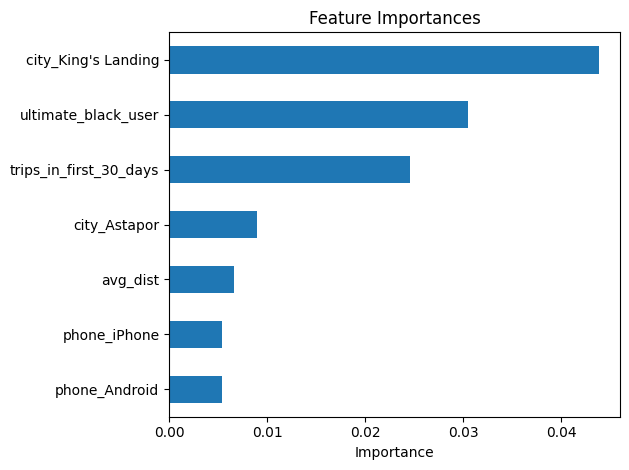

In [245]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume feature_names is your list of columns in order
feature_names = ['trips_in_first_30_days', "city_King's Landing", 'ultimate_black_user',
                 'city_Astapor', 'phone_Android', 'phone_iPhone', 'avg_dist']

importances = [0.02458673, 0.04383517, 0.03046529, 0.00896702, 0.00537053, 0.00537053, 0.00666882]

importance_series = pd.Series(importances, index=feature_names)
importance_series.sort_values().plot(kind='barh', title='Feature Importances')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 3.3. Conclusion

The modeling done in this section shows that the location of the driver is the biggest factor in determining whether they will keep using the application. The other important features are the driver being an Ultimate Black user and the number of trips they take during the first month of subsciption. Therefore, it is recommended to focus on encouraging drivers to sign up to be an Ultimate Black user, while giving them some bonuses if they consistently use the app during their first month of subscription. It is wise to focus the efforts on the two cities of King's Landing and Astapor. 